In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")
print(f"  pandas  : {pd.__version__}")
print(f"  sklearn : ", end="")
import sklearn; print(sklearn.__version__)

C:\Users\Mansoor\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Mansoor\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✓ Libraries imported
  pandas  : 3.0.2
  sklearn : 1.5.2


In [2]:
master_path = "../data/processed/master_df.parquet"
df = pd.read_parquet(master_path)

print(f"✓ Master DataFrame loaded")
print(f"  Shape   : {df.shape}")
print(f"  Columns : {df.shape[1]}")

✓ Master DataFrame loaded
  Shape   : (96470, 39)
  Columns : 39


In [3]:
df["lead_time_variance"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400  # Convert seconds → days (float)

print("✓ Target variable constructed: lead_time_variance")
print(f"\n  dtype         : {df['lead_time_variance'].dtype}")
print(f"  Null count    : {df['lead_time_variance'].isnull().sum()}")
print(f"\n  Descriptive Statistics:")
print(df["lead_time_variance"].describe().round(4).to_string())
print(f"\n  % Late  (> 0) : {(df['lead_time_variance'] > 0).mean() * 100:.2f}%")
print(f"  % Early (< 0) : {(df['lead_time_variance'] < 0).mean() * 100:.2f}%")
print(f"  % Exact (= 0) : {(df['lead_time_variance'] == 0).mean() * 100:.2f}%")

✓ Target variable constructed: lead_time_variance

  dtype         : float64
  Null count    : 0

  Descriptive Statistics:
count    96470.0000
mean       -11.1781
std         10.1844
min       -146.0161
25%        -16.2441
50%        -11.9481
75%         -6.3898
max        188.9751

  % Late  (> 0) : 8.11%
  % Early (< 0) : 91.89%
  % Exact (= 0) : 0.00%


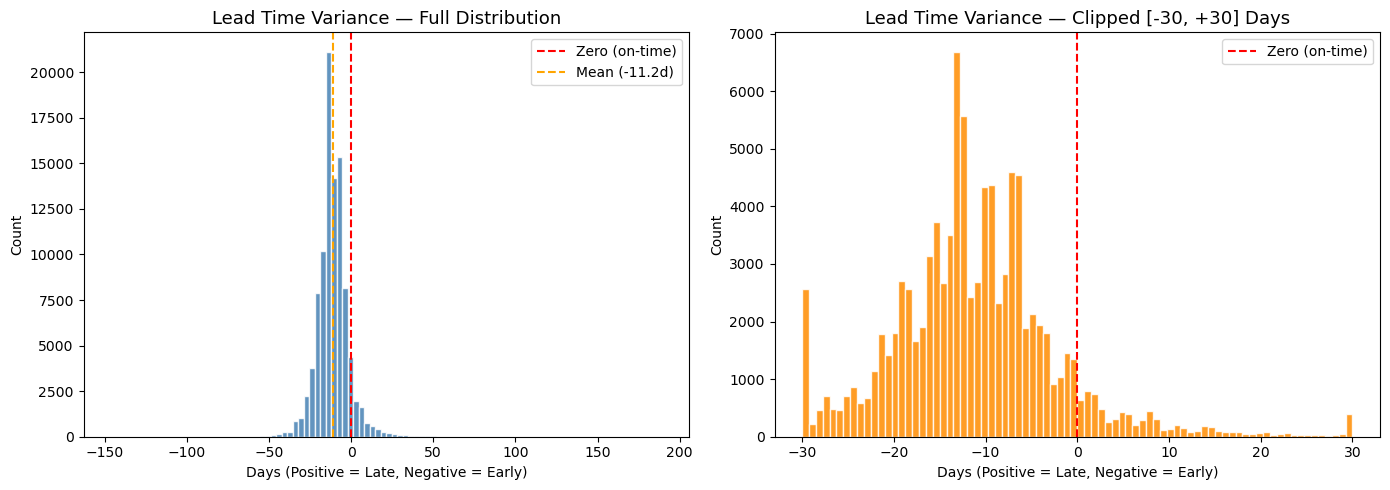

✓ Distribution plot saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Full distribution
axes[0].hist(df["lead_time_variance"], bins=100, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero (on-time)")
axes[0].axvline(df["lead_time_variance"].mean(), color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean ({df['lead_time_variance'].mean():.1f}d)")
axes[0].set_title("Lead Time Variance — Full Distribution", fontsize=13)
axes[0].set_xlabel("Days (Positive = Late, Negative = Early)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot 2 — Clipped view (-30 to +30 days) to see core distribution
clipped = df["lead_time_variance"].clip(-30, 30)
axes[1].hist(clipped, bins=80, color="darkorange", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero (on-time)")
axes[1].set_title("Lead Time Variance — Clipped [-30, +30] Days", fontsize=13)
axes[1].set_xlabel("Days (Positive = Late, Negative = Early)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Distribution plot saved")

In [5]:
null_target = df["lead_time_variance"].isnull().sum()
print(f"  Null targets before drop : {null_target}")

df = df.dropna(subset=["lead_time_variance"])
print(f"  Rows after dropping null targets : {len(df):,}")

  Null targets before drop : 0
  Rows after dropping null targets : 96,470


In [6]:
rationale = """
SPLIT STRATEGY — RATIONALE
═══════════════════════════════════════════════════════════════

  Ratio chosen  :  70% Train  |  15% Validation  |  15% Test

  Why 70/15/15 and not 80/10/10?
  ─────────────────────────────────────────────────────────────
  • Dataset has ~96K rows — large enough that 15% (~14K rows)
    gives statistically stable val/test evaluation.
  • 80/10/10 would give only ~9.6K val rows — borderline for
    reliable hyperparameter tuning across multiple models.
  • 70/15/15 keeps test set large enough to slice by category,
    seller state, etc. during error analysis.

  Why random split and NOT time-based split?
  ─────────────────────────────────────────────────────────────
  • Ideally, time-based split (train on earlier dates, test on
    later dates) is more realistic for deployment.
  • However, this dataset spans only Sep 2016 – Aug 2018
    (≈23 months). A strict time split would concentrate
    certain product categories and seller states in only
    one split, causing distribution mismatch artifacts
    unrelated to model quality.
  • We use stratified random split with a fixed random seed
    for reproducibility. We will validate temporal stability
    separately in Phase 10.

  Why split BEFORE EDA?
  ─────────────────────────────────────────────────────────────
  • All EDA insights (distributions, outlier thresholds,
    imputation values, encoding maps) must come ONLY from
    training data.
  • If EDA is done on full data first, decisions made from
    those insights (e.g. capping freight at 99th percentile)
    implicitly use test-set information → data leakage.
  • Example: if the 99th percentile of freight_value in
    the full dataset is ₹320 but in train-only it is ₹310,
    the cap value was influenced by test data.

═══════════════════════════════════════════════════════════════
"""
print(rationale)


SPLIT STRATEGY — RATIONALE
═══════════════════════════════════════════════════════════════

  Ratio chosen  :  70% Train  |  15% Validation  |  15% Test

  Why 70/15/15 and not 80/10/10?
  ─────────────────────────────────────────────────────────────
  • Dataset has ~96K rows — large enough that 15% (~14K rows)
    gives statistically stable val/test evaluation.
  • 80/10/10 would give only ~9.6K val rows — borderline for
    reliable hyperparameter tuning across multiple models.
  • 70/15/15 keeps test set large enough to slice by category,
    seller state, etc. during error analysis.

  Why random split and NOT time-based split?
  ─────────────────────────────────────────────────────────────
  • Ideally, time-based split (train on earlier dates, test on
    later dates) is more realistic for deployment.
  • However, this dataset spans only Sep 2016 – Aug 2018
    (≈23 months). A strict time split would concentrate
    certain product categories and seller states in only
    one spl

In [7]:
# Columns to EXCLUDE from features:
# - IDs (not predictive)
# - Post-purchase timestamps (leakage)
# - Raw category name (we have English version)
# - review_score (post-delivery leakage — noted in Phase 2)
# - Target itself

EXCLUDE_COLS = [
    "order_id", "customer_id", "customer_unique_id",
    "primary_seller_id", "primary_product_id",
    "order_status",                           # all 'delivered' — zero variance
    "order_approved_at",                      # post-purchase, not available at order time
    "order_delivered_carrier_date",           # post-purchase
    "order_delivered_customer_date",          # post-purchase (used to build target)
    "order_estimated_delivery_date",          # used to build target
    "order_purchase_timestamp",               # raw timestamp — features extracted later
    "product_category_name",                  # replaced by English version
    "review_score",                           # post-delivery leakage
    "review_count",                           # post-delivery leakage
    "has_review_comment",                     # post-delivery leakage
    "lead_time_variance",                     # target
]

TARGET = "lead_time_variance"

# Keep all columns not in exclude list
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f"  Total columns in master df     : {df.shape[1]}")
print(f"  Excluded columns               : {len(EXCLUDE_COLS)}")
print(f"  Feature columns kept for now   : {len(FEATURE_COLS)}")
print(f"\n  Feature columns:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"    {i:>2}. {col}")

  Total columns in master df     : 40
  Excluded columns               : 16
  Feature columns kept for now   : 24

  Feature columns:
     1. customer_zip_code_prefix
     2. customer_city
     3. customer_state
     4. item_count
     5. total_price
     6. total_freight
     7. avg_price
     8. unique_sellers
     9. unique_products
    10. seller_zip_code_prefix
    11. seller_city
    12. seller_state
    13. product_name_lenght
    14. product_description_lenght
    15. product_photos_qty
    16. product_weight_g
    17. product_length_cm
    18. product_height_cm
    19. product_width_cm
    20. product_category_name_english
    21. total_payment_value
    22. payment_installments
    23. payment_methods_used
    24. primary_payment_type


In [8]:
RANDOM_STATE = 42

# Step 1: Split off test (15%)
df_train_val, df_test = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_STATE
)

# Step 2: Split remaining into train (70%) and val (15%)
# 15% of total = 17.647% of remaining 85%
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.1765,
    random_state=RANDOM_STATE
)

print("✓ Split complete")
print(f"\n  Total rows    : {len(df):,}")
print(f"  Train rows    : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val rows      : {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test rows     : {len(df_test):,}  ({len(df_test)/len(df)*100:.1f}%)")

# Sanity: no overlap
train_ids = set(df_train["order_id"])
val_ids   = set(df_val["order_id"])
test_ids  = set(df_test["order_id"])

print(f"\n  Train ∩ Val overlap  : {len(train_ids & val_ids)}")
print(f"  Train ∩ Test overlap : {len(train_ids & test_ids)}")
print(f"  Val   ∩ Test overlap : {len(val_ids & test_ids)}")

✓ Split complete

  Total rows    : 96,470
  Train rows    : 67,526  (70.0%)
  Val rows      : 14,473  (15.0%)
  Test rows     : 14,471  (15.0%)

  Train ∩ Val overlap  : 0
  Train ∩ Test overlap : 0
  Val   ∩ Test overlap : 0


In [9]:
print("TARGET VARIABLE STATISTICS PER SPLIT\n")
print(f"  {'Metric':<20} {'Full':>12} {'Train':>12} {'Val':>12} {'Test':>12}")
print("  " + "-" * 72)

metrics = ["mean", "std", "min", "25%", "50%", "75%", "max"]
full_desc  = df["lead_time_variance"].describe()
train_desc = df_train["lead_time_variance"].describe()
val_desc   = df_val["lead_time_variance"].describe()
test_desc  = df_test["lead_time_variance"].describe()

for m in metrics:
    print(f"  {m:<20} {full_desc[m]:>12.3f} {train_desc[m]:>12.3f} "
          f"{val_desc[m]:>12.3f} {test_desc[m]:>12.3f}")

print(f"\n  {'% Late (>0)':<20} "
      f"{(df['lead_time_variance']>0).mean()*100:>11.2f}% "
      f"{(df_train['lead_time_variance']>0).mean()*100:>11.2f}% "
      f"{(df_val['lead_time_variance']>0).mean()*100:>11.2f}% "
      f"{(df_test['lead_time_variance']>0).mean()*100:>11.2f}%")

print(f"  {'% Early (<0)':<20} "
      f"{(df['lead_time_variance']<0).mean()*100:>11.2f}% "
      f"{(df_train['lead_time_variance']<0).mean()*100:>11.2f}% "
      f"{(df_val['lead_time_variance']<0).mean()*100:>11.2f}% "
      f"{(df_test['lead_time_variance']<0).mean()*100:>11.2f}%")

TARGET VARIABLE STATISTICS PER SPLIT

  Metric                       Full        Train          Val         Test
  ------------------------------------------------------------------------
  mean                      -11.178      -11.177      -11.142      -11.221
  std                        10.184       10.185       10.512        9.845
  min                      -146.016     -146.016     -134.309      -77.324
  25%                       -16.244      -16.244      -16.222      -16.260
  50%                       -11.948      -11.987      -11.506      -11.772
  75%                        -6.390       -6.394       -6.405       -6.365
  max                       188.975      188.975      165.634      152.683

  % Late (>0)                 8.11%        8.11%        8.22%        8.01%
  % Early (<0)               91.89%       91.89%       91.78%       91.99%


In [10]:
os.makedirs("../data/processed/splits", exist_ok=True)

df_train.to_parquet("../data/processed/splits/train.parquet", index=False)
df_val.to_parquet("../data/processed/splits/val.parquet", index=False)
df_test.to_parquet("../data/processed/splits/test.parquet", index=False)

print("✓ Splits saved to ../data/processed/splits/")
print(f"\n  train.parquet : {os.path.getsize('../data/processed/splits/train.parquet')/1024/1024:.2f} MB  | {len(df_train):,} rows")
print(f"  val.parquet   : {os.path.getsize('../data/processed/splits/val.parquet')/1024/1024:.2f} MB  | {len(df_val):,} rows")
print(f"  test.parquet  : {os.path.getsize('../data/processed/splits/test.parquet')/1024/1024:.2f} MB  | {len(df_test):,} rows")

✓ Splits saved to ../data/processed/splits/

  train.parquet : 12.40 MB  | 67,526 rows
  val.parquet   : 2.94 MB  | 14,473 rows
  test.parquet  : 2.92 MB  | 14,471 rows


In [11]:
import subprocess

commands = [
    ["dvc", "add", "data/processed/splits/train.parquet"],
    ["dvc", "add", "data/processed/splits/val.parquet"],
    ["dvc", "add", "data/processed/splits/test.parquet"],
]

for cmd in commands:
    result = subprocess.run(cmd, capture_output=True, text=True, cwd="../")
    if result.returncode == 0:
        print(f"✓ DVC tracked: {cmd[-1]}")
    else:
        print(f"⚠ DVC issue for {cmd[-1]}:")
        print(result.stderr[:300])

✓ DVC tracked: data/processed/splits/train.parquet
✓ DVC tracked: data/processed/splits/val.parquet
✓ DVC tracked: data/processed/splits/test.parquet


In [12]:
import json
from datetime import datetime

metadata = {
    "created_at"       : datetime.now().isoformat(),
    "random_state"     : RANDOM_STATE,
    "total_rows"       : len(df),
    "train_rows"       : len(df_train),
    "val_rows"         : len(df_val),
    "test_rows"        : len(df_test),
    "train_pct"        : round(len(df_train) / len(df) * 100, 2),
    "val_pct"          : round(len(df_val) / len(df) * 100, 2),
    "test_pct"         : round(len(df_test) / len(df) * 100, 2),
    "target_col"       : TARGET,
    "feature_cols"     : FEATURE_COLS,
    "excluded_cols"    : EXCLUDE_COLS,
    "target_train_mean": round(df_train["lead_time_variance"].mean(), 4),
    "target_val_mean"  : round(df_val["lead_time_variance"].mean(), 4),
    "target_test_mean" : round(df_test["lead_time_variance"].mean(), 4),
}

meta_path = "../data/processed/splits/split_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Split metadata saved to: {meta_path}")
print(f"\n  Preview:")
for k, v in metadata.items():
    if k not in ["feature_cols", "excluded_cols"]:
        print(f"    {k:<25} : {v}")

✓ Split metadata saved to: ../data/processed/splits/split_metadata.json

  Preview:
    created_at                : 2026-05-08T08:21:13.339102
    random_state              : 42
    total_rows                : 96470
    train_rows                : 67526
    val_rows                  : 14473
    test_rows                 : 14471
    train_pct                 : 70.0
    val_pct                   : 15.0
    test_pct                  : 15.0
    target_col                : lead_time_variance
    target_train_mean         : -11.1765
    target_val_mean           : -11.1422
    target_test_mean          : -11.2214
